# KSP 6.0 Selection Assignment

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Section 1: Computational Astronomy

### Part A
In this part, we will try to characterise the orbit of an object orbiting another object in a circular orbit.


Suppose we are observing a star orbiting a black hole.
The black hole will not be visible, however the star will be visible through some kind of telescope.

In astronomy, we use an ["Equatorial Coordinate System"](https://en.wikipedia.org/wiki/Equatorial_coordinate_system) to write down the positions of celestial bodies. This consists of two coordinates, a longitude-like ["Right Ascension"](https://en.wikipedia.org/wiki/Right_ascension)("RA") and a latitude-like ["Declination"](https://en.wikipedia.org/wiki/Declination). However, celestial bodies are not fixed but move constantly. This is captured as a phenomenon called ["Proper Motion"](https://en.wikipedia.org/wiki/Proper_motion).

Additionally, the plane of orbit need not be perpendicular to our line of sight. This will lead to distortions in the orbit.

You are given observed RA (in hours )and Dec (in degrees) of the celestial body. We are also given that the celestial body is $R = 6.9 \times 10^{19}m$ away from us. You are also given the radial velocity of the object (in $m/s$) from us.

Firstly, write code to import the data from "simple.csv". For your convenience, write it to accept any filename. It should output data as a numpy array of shape N×4.

In [2]:
def load_data(filename):
    return np.loadtxt(filename, delimiter=',',skiprows=2)
data=load_data("body_data.csv")
print(data)
    

[[ 8.03945287e+03 -1.49682295e-09 -1.18542798e-07 -3.69338314e+04]
 [ 1.60789057e+04 -1.97899210e-09 -1.21038129e-07 -6.37342191e+04]
 [ 2.41183586e+04 -2.85942119e-09 -1.11284496e-07 -9.03260449e+04]
 ...
 [ 8.03704103e+07 -3.04447752e-07 -4.57026891e-06 -7.14713588e+04]
 [ 8.03784498e+07 -3.05303469e-07 -4.57949093e-06 -9.79856654e+04]
 [ 8.03864893e+07 -3.06631888e-07 -4.57686661e-06 -1.24174368e+05]]


To convert change in RA to angle measurements in that direction, we need to adjust it by a factor dependent on the mean position of the celestial body. Convert both the data into mas (milli arc seconds). The data is given with the respect to the origin point $53^\circ 47' 31''$ declination and $12h 14m 43s$ as the RA. Convert it to mas wrt the same point in the below cell


In [3]:
def convert_entire_file(input_file, output_file):
    data=load_data(input_file)
#conversion factor: radians to milliseconds
rad_to_mas= 180/np.pi*3600*1000
RA_mas= data[:,1]*rad_to_mas
Dec_mas= data[:,2]*rad_to_mas
print("RA (mas):", RA_mas)
print("Dec (mas):", Dec_mas)

RA (mas): [ -0.3087419   -0.40819642  -0.58979796 ... -62.79685652 -62.9733608
 -63.24736691]
Dec (mas): [ -24.45120728  -24.96590616  -22.95407504 ... -942.68563081 -944.58781005
 -944.04650355]


In [4]:
data_mas=np.column_stack((data[:,0], RA_mas, Dec_mas, data[:,3]))
np.savetxt("data_mas.csv",data_mas, delimiter=',',
          header="Time,RA(mas),Dec(mas),RadialVelocity", comments="",fmt='%6f')

Now, plot the loaded data using matplotlib the coordinates in milli arcseconds on the two axes.

In [5]:
def load_data(filename):
    return np.loadtxt(filename, delimiter=',',skiprows=1)
data_mas=load_data("data_mas.csv")
print(data)

[[ 8.03945287e+03 -1.49682295e-09 -1.18542798e-07 -3.69338314e+04]
 [ 1.60789057e+04 -1.97899210e-09 -1.21038129e-07 -6.37342191e+04]
 [ 2.41183586e+04 -2.85942119e-09 -1.11284496e-07 -9.03260449e+04]
 ...
 [ 8.03704103e+07 -3.04447752e-07 -4.57026891e-06 -7.14713588e+04]
 [ 8.03784498e+07 -3.05303469e-07 -4.57949093e-06 -9.79856654e+04]
 [ 8.03864893e+07 -3.06631888e-07 -4.57686661e-06 -1.24174368e+05]]


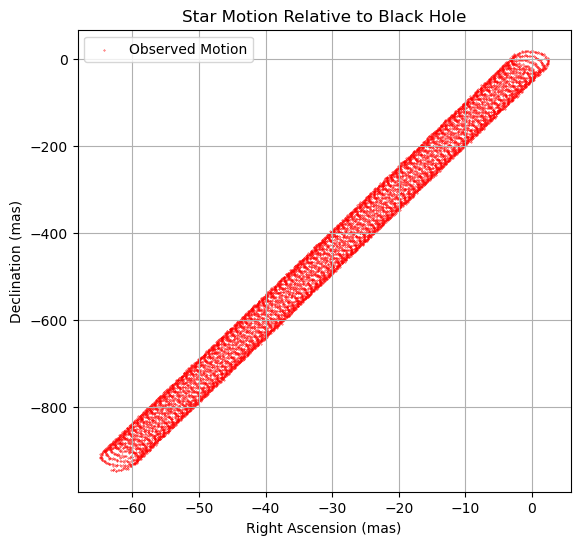

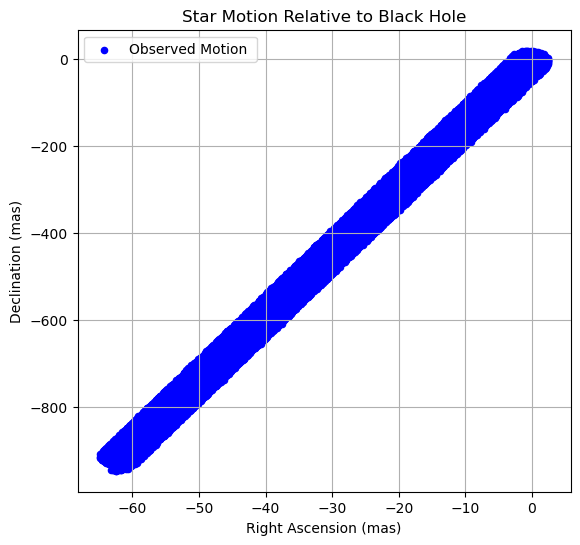

In [6]:
# Load converted data (RA/Dec in mas)
time = data_mas[:, 0]          # Column 0: Time
RA_mas = data_mas[:, 1]        # Column 1: RA (mas)
Dec_mas = data_mas[:, 2]       # Column 2: Dec (mas)

# Plot RA vs. Dec
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.scatter(RA_mas, Dec_mas, color='r', s=0.1, label="Observed Motion")
plt.xlabel("Right Ascension (mas)")
plt.ylabel("Declination (mas)")
plt.title("Star Motion Relative to Black Hole")
plt.grid(True)
plt.legend()
plt.show()
plt.figure(figsize=(14, 6))
plt.subplot(1,2,2)
plt.scatter(RA_mas, Dec_mas, color='b', s=20, label="Observed Motion ")
plt.xlabel("Right Ascension (mas)")
plt.ylabel("Declination (mas)")
plt.title("Star Motion Relative to Black Hole")
plt.grid(True)
plt.legend()
plt.show()

Next, we need to remove the proper motion of the black hole, which we see as moving in a straight line. Motion of the star is the resultant of the orbit and the proper motion of the black hole. Using the fact that the orbital motion is periodic, find the proper motion $(\mu_\alpha, \mu_\delta)$ and return it as a tuple.

In [7]:
def proper_motion(data_mas):
    time = data_mas[:, 0]         
    RA_mas = data_mas[:, 1]        
    Dec_mas = data_mas[:, 2]   
    μ_α = np.polyfit(time, RA_mas, 1)[0]   # Proper motion in RA (mas/time)
    μ_δ= np.polyfit(time, Dec_mas, 1)[0]   # Proper motion in Dec (mas/time)
    return(μ_α, μ_δ)


Now, we can remove the effect of proper motion, which is simply a constant-velocity like motion. Modify the data to remove its effect and return data.

In [8]:
def remove_proper_motion(data_mas, μ_δ, μ_α):
    time = data_mas[:, 0]         
    RA_mas = data_mas[:, 1]        
    Dec_mas = data_mas[:, 2]
    
    # Subtract the linear proper motion
    corrected_RA = RA_mas - (μ_α * time)  # Correct RA
    corrected_Dec = Dec_mas - (μ_δ * time)  # Correct Dec
    
    # corrected data array
    corrected_data_mas=np.column_stack((time, corrected_RA, corrected_Dec, data_mas[:,3]))
    
    return corrected_data_mas

In [9]:
# Calculate proper motion
μ_α, μ_δ = proper_motion(data_mas)

# Remove proper motion
corrected_data_mas = remove_proper_motion(data_mas, μ_δ, μ_α)
#save to csv
np.savetxt("corrected_data_mas.csv",
           corrected_data_mas, delimiter=',',
           header="Time,RA_corrected(mas),Dec_corrected(mas),RadialVelocity", comments="",fmt='%6f')

Plot the data corrected for proper motion. The data should now form a closed loop.

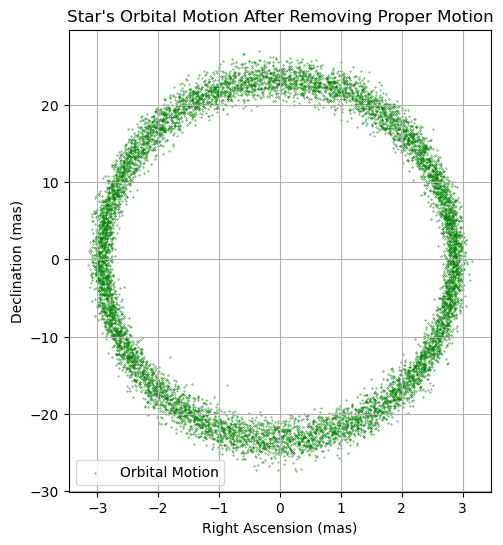

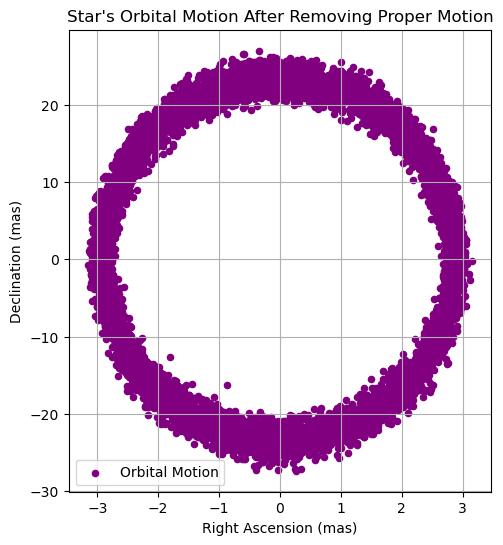

In [10]:
# Plot the corrected data
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.scatter(corrected_data_mas[:, 1], corrected_data_mas[:, 2], color='green', s=0.1, label="Orbital Motion")
plt.xlabel("Right Ascension (mas)")
plt.ylabel("Declination (mas)")
plt.title("Star's Orbital Motion After Removing Proper Motion")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1,2,2)
plt.scatter(corrected_data_mas[:, 1], corrected_data_mas[:, 2], color='purple', s=20, label="Orbital Motion")
plt.xlabel("Right Ascension (mas)")
plt.ylabel("Declination (mas)")
plt.title("Star's Orbital Motion After Removing Proper Motion")
plt.grid(True)
plt.legend()
plt.show()

The orbit of the star is circular, but it may not orbit with the plane perpendicular to our line of sight. This discrepancy is called [inclination](https://en.wikipedia.org/wiki/Orbital_inclination), which leads to the orbit not visually looking circular. Find the inclination of the orbit, with or without using the radial velocity data.

In [11]:
def inclination(corrected_data_mas):
    # corrected_data_mas contains [time, x_position, y_position, radial_velocity]
    x = corrected_data_mas[:, 1]  # Get all x positions
    y = corrected_data_mas[:, 2]  # Get all y positions
    
    # Find how stretched the orbit looks
    x_span = (max(x) - min(x))/2
    y_span = (max(y) - min(y))/2
    
    if x_span >=y_span:
        tilt_angle=np.arccos(y_span/x_span)
    else:
        tilt_angle=np.arccos(x_span/y_span)
    return tilt_angle

To really understand the orbit, we should view it from "above" the plane of motion. To achieve that, we must therefore rotate the orbit about the "reference line" by the inclination. Through that, create an N×3 numpy array of timestamped planar motion.

In [12]:
def rotate_orbit(corrected_data_mas):
    # First find how much it's tilted
    tilt_angle = inclination(corrected_data_mas)
    
    # Get positions
    x = corrected_data_mas[:, 1]  # Get all x positions
    y = corrected_data_mas[:, 2]  # Get all y positions
    z=np.zeros_like(x)
    
    # applying rotation about x
    x_rot=x
    y_rot=y*np.cos(tilt_angle)-z*np.sin(tilt_angle)
    z_rot=y*np.sin(tilt_angle)+z*np.cos(tilt_angle)
    
    rotated_data =np.column_stack((corrected_data_mas[:,0],x_rot, y_rot))
   
    # Return fixed orbit with same times
    return rotated_data

In [13]:
rotated_data = rotate_orbit(corrected_data_mas)
#save to csv
np.savetxt("rotated_data.csv",
           rotated_data, delimiter=',',
           header="Time,x,y", comments="",fmt='%6f')
    

In [14]:
def load_data(filename):
    return np.loadtxt(filename, delimiter=',',skiprows=1)
data_1=load_data("rotated_data.csv")
print(data)

[[ 8.03945287e+03 -1.49682295e-09 -1.18542798e-07 -3.69338314e+04]
 [ 1.60789057e+04 -1.97899210e-09 -1.21038129e-07 -6.37342191e+04]
 [ 2.41183586e+04 -2.85942119e-09 -1.11284496e-07 -9.03260449e+04]
 ...
 [ 8.03704103e+07 -3.04447752e-07 -4.57026891e-06 -7.14713588e+04]
 [ 8.03784498e+07 -3.05303469e-07 -4.57949093e-06 -9.79856654e+04]
 [ 8.03864893e+07 -3.06631888e-07 -4.57686661e-06 -1.24174368e+05]]


Plot this corrected data using matplotlib.

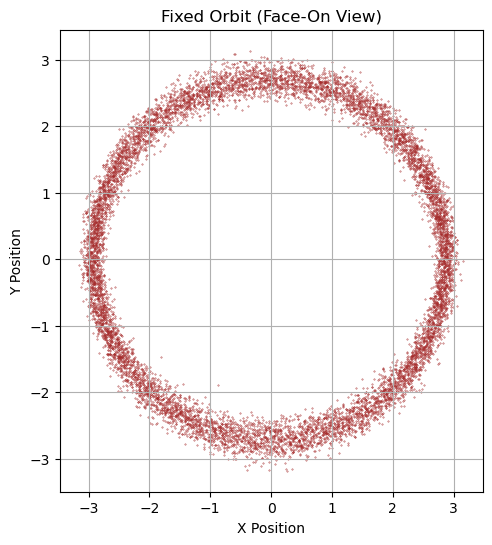

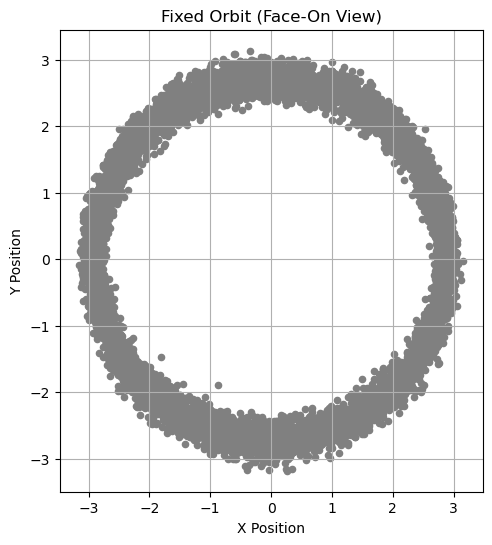

In [15]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(rotated_data[:,1], rotated_data[:,2], color='brown',s=0.1, label="Orbital Motion")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Fixed Orbit (Face-On View)")
plt.grid(True)
plt.show()
plt.figure(figsize=(12,6))
plt.subplot(1,2,2)
plt.scatter(rotated_data[:,1], rotated_data[:,2],color='gray', s=20, label="Orbital Motion")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Fixed Orbit (Face-On View)")
plt.grid(True)
plt.show()

Now, we can calculate the radius $r$ of the orbit. Return $r$

In [16]:
def radius(rotated_data):
    x=rotated_data[:,1]
    y=rotated_data[:,2]
    
    distances= np.sqrt(x**2+y**2)
    r=np.mean(distances)
    return r

In [17]:
r=radius(rotated_data)
print(f"Radius of the orbit:{r:.6f}units")

Radius of the orbit:2.807845units


Find the time period of the orbit using the final rotated orbital data.

In [20]:
def time_period(rotated_data):
    time = rotated_data[:, 0]  # Time values
    x = rotated_data[:, 1]     # x positions
    
    # Find peaks (approximate maxima)
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(x)  # Detect peaks in x
    
    if len(peaks) < 2:
        raise ValueError("Insufficient data to determine period.")
    
    # Time differences between consecutive peaks
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    t=np.mean(periods)
    # Return average period
    return t

In [22]:
t=time_period(rotated_data)
print(f"Time period of the orbit:{t:.6f} units")

Time period of the orbit:43291.695269 units


Using the radius of the orbit and the time period, find the mass $M$ of the parent object (assuming it is much more massive than the daughter object). Return $M$.


In [24]:
def M(radius, time_period):
    G = 6.67430e-11
    M = (4 * np.pi**2 * r**3) / (G * t**2)
    return M

In [25]:
M=M(radius, time_period)
print(f"Mass M  of the parent object :{M:.6f} kg")

Mass M  of the parent object :6986.574194 units


Finally, combine all of the above functions to report the mass of the parent object in the form M

In [37]:
def report_mass(rotated_data ):
    
    # Step 2: Calculate radius
    r = radius(rotated_data)
    
    # Step 3: Calculate time period
    t = time_period(rotated_data)
    
    # Step 4: Calculate mass
    G = 6.67430e-11
    parent_mass =M = (4 * np.pi**2 * r**3) / (G * t**2) #M(r,t)
    
    
    return parent_mass

In [38]:
parent_mass=report_mass(rotated_data)
print(f"Mass of the parent object: {parent_mass:.2e} kg")

Mass of the parent object: 6.99e+03 kg


## Section 2: Theoretical Astronomy

Find the problems in the following PDF in the repo and add markdown and answer the questions: